In [ ]:
# DAY 11 - CELL 1
# Import required libraries and connect Google Drive

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Underwater-Image-Data-set-main"

print("Dataset path:", BASE_PATH)
print("Path exists:", os.path.exists(BASE_PATH))

Mounted at /content/drive
Dataset path: /content/drive/MyDrive/Underwater-Image-Data-set-main
Path exists: True


In [ ]:
# DAY 11 - CELL 2
# Collect all complete Input-Target pairs

pairs = []

for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if "_input" in file.lower() and file.lower().endswith((".png", ".jpg", ".jpeg")):

            input_path = os.path.join(root, file)
            sample_id = file.rsplit("_input", 1)[0]

            target_path = os.path.join(root, sample_id + "_target.png")

            if os.path.exists(target_path):
                pairs.append((input_path, target_path))

print("Total Input-Target pairs:", len(pairs))

print("\nExample pair:")
print("Input :", pairs[0][0])
print("Target:", pairs[0][1])

Total Input-Target pairs: 1233

Example pair:
Input : /content/drive/MyDrive/Underwater-Image-Data-set-main/epoch_0135/epoch_0135/img 138_input.png
Target: /content/drive/MyDrive/Underwater-Image-Data-set-main/epoch_0135/epoch_0135/img 138_target.png


In [ ]:
# DAY 11 - CELL 3
# Create leakage-safe Train / Validation / Test splits

from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.30,
    random_state=42
)

# Second split: divide temporary data equally
val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=42
)

print("Training pairs   :", len(train_pairs))
print("Validation pairs :", len(val_pairs))
print("Testing pairs    :", len(test_pairs))
print("Total pairs      :", len(train_pairs) + len(val_pairs) + len(test_pairs))

Training pairs   : 863
Validation pairs : 185
Testing pairs    : 185
Total pairs      : 1233


In [ ]:
# DAY 11 - CELL 4
# Check that there is no overlap between Train, Validation and Test sets

train_inputs = set([pair[0] for pair in train_pairs])
val_inputs = set([pair[0] for pair in val_pairs])
test_inputs = set([pair[0] for pair in test_pairs])

print("Train-Val overlap :", len(train_inputs.intersection(val_inputs)))
print("Train-Test overlap:", len(train_inputs.intersection(test_inputs)))
print("Val-Test overlap  :", len(val_inputs.intersection(test_inputs)))

if (len(train_inputs.intersection(val_inputs)) == 0 and
    len(train_inputs.intersection(test_inputs)) == 0 and
    len(val_inputs.intersection(test_inputs)) == 0):
    print("\nNo overlap found. Split is leakage-safe.")
else:
    print("\nOverlap found. Check the dataset split.")

Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0

No overlap found. Split is leakage-safe.


In [ ]:
# DAY 11 - CELL 5
# Preprocessing: Resize images to 256 × 256 and normalize pixel values to 0–1

def preprocess_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((256, 256))

    image_array = np.array(image, dtype=np.float32)
    image_array = image_array / 255.0

    return image_array

# Test preprocessing on one Input-Target pair
input_image = preprocess_image(train_pairs[0][0])
target_image = preprocess_image(train_pairs[0][1])

print("Input shape:", input_image.shape)
print("Target shape:", target_image.shape)

print("Input minimum:", input_image.min())
print("Input maximum:", input_image.max())

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)
Input minimum: 0.0
Input maximum: 1.0


In [ ]:
# DAY 11 - CELL 6
# Create PyTorch Dataset for Input-Target image pairs

import torch
from torch.utils.data import Dataset

class UnderwaterDataset(Dataset):

    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):

        input_path, target_path = self.pairs[index]

        input_image = preprocess_image(input_path)
        target_image = preprocess_image(target_path)

        input_image = torch.from_numpy(input_image).permute(2, 0, 1)
        target_image = torch.from_numpy(target_image).permute(2, 0, 1)

        return input_image, target_image


train_dataset = UnderwaterDataset(train_pairs)
val_dataset = UnderwaterDataset(val_pairs)
test_dataset = UnderwaterDataset(test_pairs)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Testing dataset:", len(test_dataset))

Training dataset: 863
Validation dataset: 185
Testing dataset: 185


In [ ]:
# DAY 11 - CELL 7
# Create DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Testing batches    :", len(test_loader))

Training batches   : 108
Validation batches : 24
Testing batches    : 24


In [ ]:
# DAY 11 - CELL 8
# Check one batch from the training DataLoader

input_batch, target_batch = next(iter(train_loader))

print("Input batch shape :", input_batch.shape)
print("Target batch shape:", target_batch.shape)

print("Input minimum :", input_batch.min().item())
print("Input maximum :", input_batch.max().item())

print("Target minimum :", target_batch.min().item())
print("Target maximum :", target_batch.max().item())

Input batch shape : torch.Size([8, 3, 256, 256])
Target batch shape: torch.Size([8, 3, 256, 256])
Input minimum : 0.0
Input maximum : 0.9764705896377563
Target minimum : 0.0
Target maximum : 1.0


In [ ]:
# DAY 11 - CELL 9
# Save preprocessing configuration

import json

config = {
    "version": "Dataset_V1",
    "image_size": [256, 256],
    "normalization": "pixel_value / 255.0",
    "pixel_range": [0, 1],
    "channels": 3,
    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    },
    "batch_size": 8,
    "random_state": 42
}

config_path = os.path.join(BASE_PATH, "preprocessing_config_v1.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Configuration saved successfully.")
print("File:", config_path)

Configuration saved successfully.
File: /content/drive/MyDrive/Underwater-Image-Data-set-main/preprocessing_config_v1.json


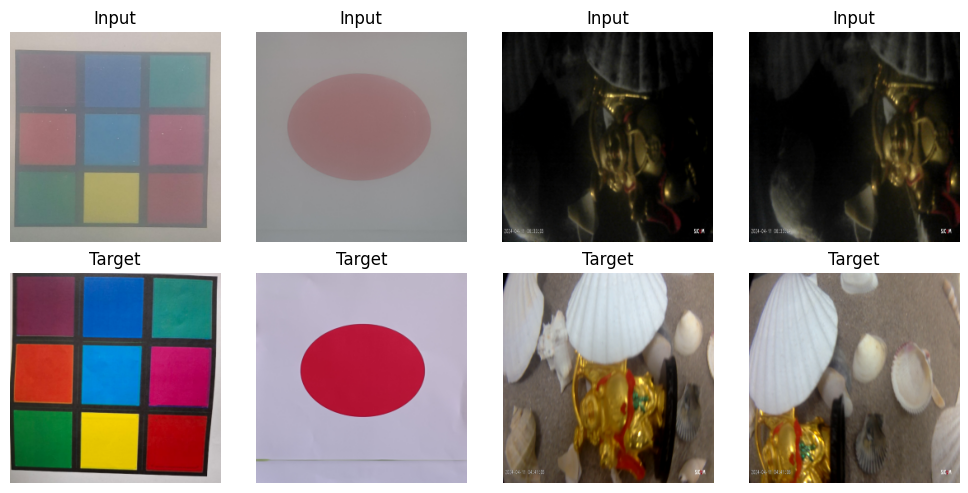

In [ ]:
# DAY 11 - CELL 10
# Visualize Input and Target images from one batch

input_batch, target_batch = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(input_batch[i].permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("Input")

    plt.subplot(2, 4, i + 5)
    plt.imshow(target_batch[i].permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("Target")

plt.tight_layout()
plt.show()